# PANDAS -> Szybka analiza danych klienta

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#ramka danych
data = {
    "customer_id":[101,102,103,104,105,106],
    "age":[25,42,37,np.nan,29,57],
    "city":["Warszawa","Kraków","Wrocław","Warszawa","Kraków","Wrocław"],
    "income":[4500,9200,6700,5800,np.nan,12000],
    "purchased":[3,7,5,2,4,9]
}

df = pd.DataFrame(data)
df

,customer_id,age,city,income,purchased
0,101,25.0,Warszawa,4500.0,3
1,102,42.0,Kraków,9200.0,7
2,103,37.0,Wrocław,6700.0,5
3,104,NaN,Warszawa,5800.0,2
4,105,29.0,Kraków,NaN,4
5,106,57.0,Wrocław,12000.0,9


In [ ]:
#analiza ramki
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  6 non-null      int64  
 1   age          5 non-null      float64
 2   city         6 non-null      object 
 3   income       5 non-null      float64
 4   purchased    6 non-null      int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 372.0+ bytes


In [ ]:
#statystyki opisowe
df.describe()

,customer_id,age,income,purchased
count,6.000000,5.000000,5.000000,6.000000
mean,103.500000,38.000000,7640.000000,5.000000
std,1.870829,12.529964,2982.113345,2.607681
min,101.000000,25.000000,4500.000000,2.000000
25%,102.250000,29.000000,5800.000000,3.250000
50%,103.500000,37.000000,6700.000000,4.500000
75%,104.750000,42.000000,9200.000000,6.500000
max,106.000000,57.000000,12000.000000,9.000000


In [ ]:
df.isna().sum()

,0
customer_id,0
age,1
city,0
income,1
purchased,0


In [ ]:
#średni dochód wg miasta
df.groupby("city")["income"].mean()

,income
city,
Kraków,9200.0
Warszawa,5150.0
Wrocław,9350.0


In [ ]:
#klienci z zakupami pow.4
df[df["purchased"]>4]

,customer_id,age,city,income,purchased
1,102,42.0,Kraków,9200.0,7
2,103,37.0,Wrocław,6700.0,5
5,106,57.0,Wrocław,12000.0,9


# Czyszczenie danych i przygotowanie cech

In [14]:
data = {
    "name":["Anna","Marek","Kasia","Piotr","Ewa"],
    "age":[23,np.nan,35,28,np.nan],
    "salary":[5000,7200,None,6500,8000],
    "departament":["IT","HR","Sales","HR","IT"]
}

df = pd.DataFrame(data)
df


,name,age,salary,departament
0,Anna,23.0,5000.0,IT
1,Marek,NaN,7200.0,HR
2,Kasia,35.0,NaN,Sales
3,Piotr,28.0,6500.0,HR
4,Ewa,NaN,8000.0,IT


In [15]:
#uzupełnienie braków mediana
df["age"] = df["age"].fillna(df["age"].median())
df

,name,age,salary,departament
0,Anna,23.0,5000.0,IT
1,Marek,28.0,7200.0,HR
2,Kasia,35.0,NaN,Sales
3,Piotr,28.0,6500.0,HR
4,Ewa,28.0,8000.0,IT


In [16]:
df["salary"] = df["salary"].fillna(df["salary"].median())
df

,name,age,salary,departament
0,Anna,23.0,5000.0,IT
1,Marek,28.0,7200.0,HR
2,Kasia,35.0,6850.0,Sales
3,Piotr,28.0,6500.0,HR
4,Ewa,28.0,8000.0,IT


In [17]:
#towrzenie nowej cechy
df["salary_per_age"] = df["salary"]/df["age"]
df

,name,age,salary,departament,salary_per_age
0,Anna,23.0,5000.0,IT,217.391304
1,Marek,28.0,7200.0,HR,257.142857
2,Kasia,35.0,6850.0,Sales,195.714286
3,Piotr,28.0,6500.0,HR,232.142857
4,Ewa,28.0,8000.0,IT,285.714286


In [20]:
#kodowanie kategorii
df_encoded = pd.get_dummies(df,columns=["departament"],drop_first=False)
df_encoded

,name,age,salary,salary_per_age,departament_HR,departament_IT,departament_Sales
0,Anna,23.0,5000.0,217.391304,False,True,False
1,Marek,28.0,7200.0,257.142857,True,False,False
2,Kasia,35.0,6850.0,195.714286,False,False,True
3,Piotr,28.0,6500.0,232.142857,True,False,False
4,Ewa,28.0,8000.0,285.714286,False,True,False


In [19]:
df

,name,age,salary,departament,salary_per_age
0,Anna,23.0,5000.0,IT,217.391304
1,Marek,28.0,7200.0,HR,257.142857
2,Kasia,35.0,6850.0,Sales,195.714286
3,Piotr,28.0,6500.0,HR,232.142857
4,Ewa,28.0,8000.0,IT,285.714286


# Analiza sprzedaży w czasie -> z PANDAS

In [22]:
data = {
    "date":["2025-01-03","2025-01-10","2025-02-05","2025-02-12","2025-03-01","2025-03-20"],
    "product":["A","B","C","B","A","B"],
    "sales":[1200,900,1500,1100,1300,1000]
}
df = pd.DataFrame(data)
df

,date,product,sales
0,2025-01-03,A,1200
1,2025-01-10,B,900
2,2025-02-05,C,1500
3,2025-02-12,B,1100
4,2025-03-01,A,1300
5,2025-03-20,B,1000


In [23]:
#konwersja do datetime
df["date"] = pd.to_datetime(df["date"])
df

,date,product,sales
0,2025-01-03,A,1200
1,2025-01-10,B,900
2,2025-02-05,C,1500
3,2025-02-12,B,1100
4,2025-03-01,A,1300
5,2025-03-20,B,1000


In [24]:
#cechy czasowe
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["weekday"] = df["date"].dt.day_name()
df["quarter"] = df["date"].dt.quarter

df

,date,product,sales,month,year,weekday,quarter
0,2025-01-03,A,1200,1,2025,Friday,1
1,2025-01-10,B,900,1,2025,Friday,1
2,2025-02-05,C,1500,2,2025,Wednesday,1
3,2025-02-12,B,1100,2,2025,Wednesday,1
4,2025-03-01,A,1300,3,2025,Saturday,1
5,2025-03-20,B,1000,3,2025,Thursday,1


In [25]:
#sprzedaż  wg miesiąca
df.groupby("month")["sales"].sum()

,sales
month,
1,2100
2,2600
3,2300


In [26]:
#sprzedaż wg tygodnia
df.groupby("weekday")["sales"].sum()

,sales
weekday,
Friday,2100
Saturday,1300
Thursday,1000
Wednesday,2600


In [27]:
#sprzedaż produktów "A" w czasie
df[df["product"] == "A"].sort_values("date")

,date,product,sales,month,year,weekday,quarter
0,2025-01-03,A,1200,1,2025,Friday,1
4,2025-03-01,A,1300,3,2025,Saturday,1


# Wykrywanie anomalii prostą metodą w Pandas

In [29]:
data = {
    "transaction_id":range(1,11),
    "amount":[120,135,128,140,132,125,138,5000,129,131]
}
df = pd.DataFrame(data)
df

,transaction_id,amount
0,1,120
1,2,135
2,3,128
3,4,140
4,5,132
5,6,125
6,7,138
7,8,5000
8,9,129
9,10,131


In [30]:
mean_amount = df["amount"].mean()
std_amount = df["amount"].std()

In [31]:
#Z-SCORE

df["z_score"] = (df["amount"] - mean_amount)/std_amount
df

,transaction_id,amount,z_score
0,1,120,-0.323297
1,2,135,-0.313555
2,3,128,-0.318102
3,4,140,-0.310308
4,5,132,-0.315504
5,6,125,-0.320050
6,7,138,-0.311607
7,8,5000,2.846029
8,9,129,-0.317452
9,10,131,-0.316153


In [32]:
#reguła anomalii
df["is_anomaly"] = df["z_score"].abs()>2
df

,transaction_id,amount,z_score,is_anomaly
0,1,120,-0.323297,False
1,2,135,-0.313555,False
2,3,128,-0.318102,False
3,4,140,-0.310308,False
4,5,132,-0.315504,False
5,6,125,-0.320050,False
6,7,138,-0.311607,False
7,8,5000,2.846029,True
8,9,129,-0.317452,False
9,10,131,-0.316153,False


In [33]:
df[df["is_anomaly"]]

,transaction_id,amount,z_score,is_anomaly
7,8,5000,2.846029,True


# Przygotowanie danych do prostego modelu ML

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [35]:
data = {
    "hours_studied":[1,2,3,4,5,6,7,8,2,6],
    "attendance":[50,60,65,70,80,85,90,95,55,95],
    "homework_done":[0,0,1,1,1,1,1,1,0,1],
    "passed":[0,0,0,0,1,1,1,1,0,1]
}
df = pd.DataFrame(data)
df

,hours_studied,attendance,homework_done,passed
0,1,50,0,0
1,2,60,0,0
2,3,65,1,0
3,4,70,1,0
4,5,80,1,1
5,6,85,1,1
6,7,90,1,1
7,8,95,1,1
8,2,55,0,0
9,6,95,1,1


In [36]:
X = df[["hours_studied","attendance","homework_done"]]
y = df["passed"] #etykieta -> rozwiązanie

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [38]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [39]:
y_pred = model.predict(X_test)

In [40]:
df

,hours_studied,attendance,homework_done,passed
0,1,50,0,0
1,2,60,0,0
2,3,65,1,0
3,4,70,1,0
4,5,80,1,1
5,6,85,1,1
6,7,90,1,1
7,8,95,1,1
8,2,55,0,0
9,6,95,1,1


In [41]:
y_pred

array([0, 0, 1])

In [42]:
#accuracy score
accuracy_score(y_test,y_pred)

1.0

In [44]:
#raport klasyfkacji
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### Wizualizacja funkcji Sigmoid
Funkcja sigmoidalna (logistyczna) przyjmuje dowolną wartość rzeczywistą i przekształca ją na wartość z przedziału (0, 1). Wzór funkcji to:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

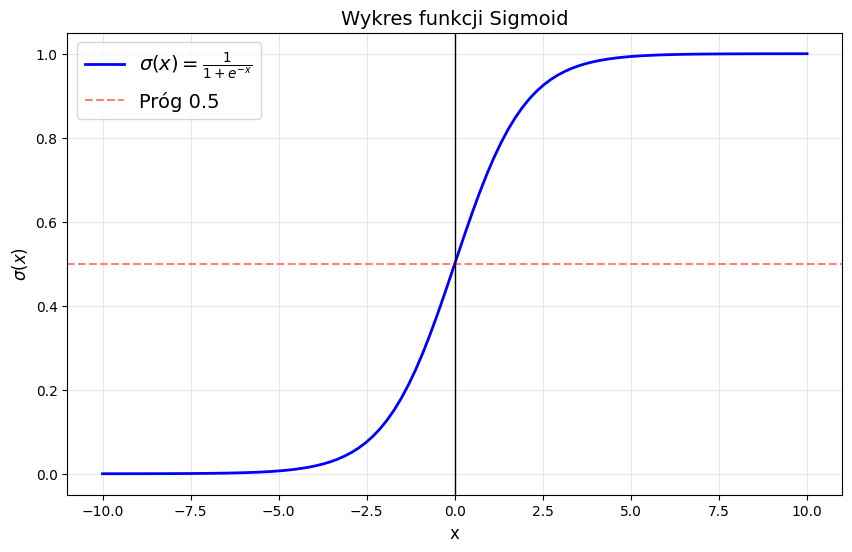

In [47]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label=r'$\sigma(x) = \frac{1}{1 + e^{-x}}$', color='blue', linewidth=2)
plt.title('Wykres funkcji Sigmoid', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel(r'$\sigma(x)$', fontsize=12)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Próg 0.5')
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.show()

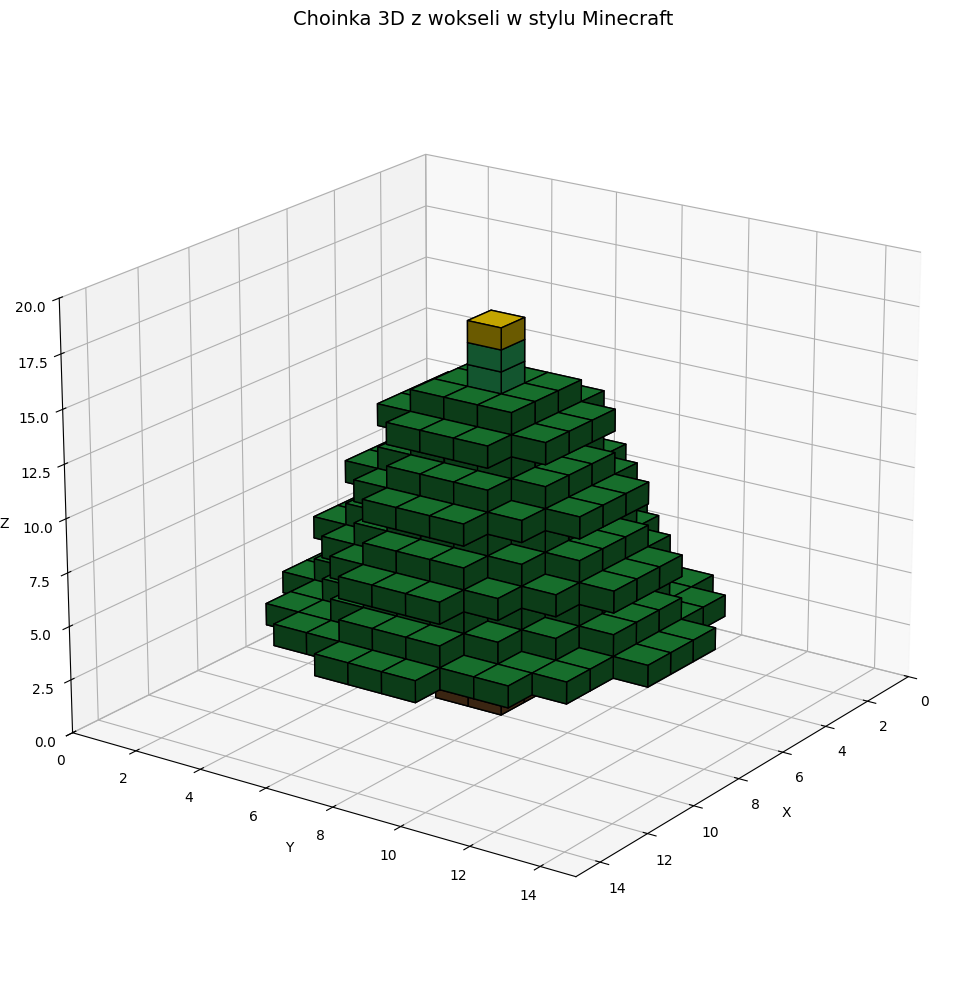

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Rozmiar przestrzeni 3D
size_x, size_y, size_z = 15, 15, 20

# Tablica wokseli: False = pusty, True = blok
voxels = np.zeros((size_x, size_y, size_z), dtype=bool)

# Tablica kolorów dla wokseli
colors = np.empty(voxels.shape, dtype=object)

# Środek choinki
cx, cy = size_x // 2, size_y // 2

# -----------------------------
# Pień
# -----------------------------
for z in range(0, 4):
    for x in range(cx - 1, cx + 1):
        for y in range(cy - 1, cy + 1):
            voxels[x, y, z] = True
            colors[x, y, z] = '#8B5A2B'   # brąz

# -----------------------------
# Warstwy choinki
# -----------------------------
base_z = 4
layer_heights = [3, 3, 3, 2]
layer_radii = [5, 4, 3, 2]

current_z = base_z

for h, r in zip(layer_heights, layer_radii):
    for dz in range(h):
        rr = max(1, r - dz)  # lekko zwężamy ku górze
        z = current_z + dz
        for x in range(cx - rr, cx + rr + 1):
            for y in range(cy - rr, cy + rr + 1):
                # lekko "okrągławy" przekrój
                if (x - cx) ** 2 + (y - cy) ** 2 <= rr ** 2 + 1:
                    voxels[x, y, z] = True
                    colors[x, y, z] = '#1E8F3A'   # zielony
    current_z += h

# -----------------------------
# Czubek
# -----------------------------
for z in range(current_z, current_z + 2):
    voxels[cx, cy, z] = True
    colors[cx, cy, z] = '#2ECC71'

# Gwiazda na szczycie
voxels[cx, cy, current_z + 2] = True
colors[cx, cy, current_z + 2] = 'gold'

# -----------------------------
# Bombki
# -----------------------------
ornaments = [
    (cx - 2, cy, 6),
    (cx + 2, cy - 1, 7),
    (cx, cy + 2, 8),
    (cx - 1, cy - 2, 9),
    (cx + 1, cy + 1, 10),
    (cx, cy - 1, 11),
]

ornament_colors = ['red', 'blue', 'yellow', 'magenta', 'cyan', 'orange']

for (x, y, z), c in zip(ornaments, ornament_colors):
    if 0 <= x < size_x and 0 <= y < size_y and 0 <= z < size_z:
        voxels[x, y, z] = True
        colors[x, y, z] = c

# -----------------------------
# Rysowanie
# -----------------------------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.voxels(voxels, facecolors=colors, edgecolor='black')

ax.set_title("Choinka 3D z wokseli w stylu Minecraft", fontsize=14)
ax.set_xlim(0, size_x)
ax.set_ylim(0, size_y)
ax.set_zlim(0, size_z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Lepszy widok
ax.view_init(elev=20, azim=35)

plt.tight_layout()
plt.show()